In [1]:
## The following code ensures that all functions and init files are reloaded before executions.
%load_ext autoreload
%autoreload 2

In [2]:
import insitupy
from insitupy._core.data import InSituData,ImageData, CACHE
from insitupy import InSituExperiment
from insitupy.io import read_xenium
import scanpy as sc
from pathlib import Path
import matplotlib.pyplot as plt

### Load Xenium data into `InSituData` object

In [3]:
insitupy_project_downscaled = Path(CACHE / "out/demo_insitupy_project")
xd = InSituData.read(insitupy_project_downscaled)
xd.load_all(skip="transcripts")
xd

C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,
C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,
C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,
C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,


InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
Path:		C:\Users\ge37voy\.cache\InSituPy\out\demo_insitupy_project

    ➤ images
       CD20:	(25778, 35416)
       HE:	(25778, 35416, 3)
       HER2:	(25778, 35416)
       nuclei:	(25778, 35416)
    ➤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs × n_vars = 156447 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc', 'cell_type_dc_sub', 'cell_type_tacco', 'cell_type_publ_x', 'cell_type_publ_y', 'cell_type_dc_sub_final', 'cell_type_publ'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_colors', 'cell_type_dc_sub', 'cell_type_dc_sub_colors', 'cell_type_dc_sub_final_colors', 'cell_type_p

### Create `InSituExperiment` from regions

In [4]:
exp = InSituExperiment.from_regions(
    data=xd, region_key="TMA"
)

A-1
A-2
A-3
B-1
B-2
B-3


In [5]:
exp

You are accessing a copy of the metadata. Changes to this DataFrame will not affect the internal metadata. Use `add_metadata_column()` or `append_metadata()` to add new information to metadata.


InSituExperiment with 6 samples:
           uid  CITAR slide_id    sample_id region_key region_name
0     41ef2fe9  ++-++  0001879  Replicate 1        TMA         A-1
1     5ab93591  ++-++  0001879  Replicate 1        TMA         A-2
2     1bb166a3  ++-++  0001879  Replicate 1        TMA         A-3
3     e252ed87  ++-++  0001879  Replicate 1        TMA         B-1
4     1680f11f  ++-++  0001879  Replicate 1        TMA         B-2
5     d7a51683  ++-++  0001879  Replicate 1        TMA         B-3

### Generating dummy conditions for pseudobulk analysis

In [6]:
exp.add_metadata_column(
    column_name="condition",
    values=["A", "A", "A", "B", "B", "B"])

In [7]:
exp.metadata

You are accessing a copy of the metadata. Changes to this DataFrame will not affect the internal metadata. Use `add_metadata_column()` or `append_metadata()` to add new information to metadata.


,uid,slide_id,sample_id,region_key,region_name,condition
0,41ef2fe9,0001879,Replicate 1,TMA,A-1,A
1,5ab93591,0001879,Replicate 1,TMA,A-2,A
2,1bb166a3,0001879,Replicate 1,TMA,A-3,A
3,e252ed87,0001879,Replicate 1,TMA,B-1,B
4,1680f11f,0001879,Replicate 1,TMA,B-2,B
5,d7a51683,0001879,Replicate 1,TMA,B-3,B


## Generate pseudobulk 

A more detailed tutorial on the pseudobulk analysis can be found in the [documentation of the decoupler package](https://decoupler.readthedocs.io/en/latest/notebooks/scell/rna_psbk.html).

In [8]:
import decoupler as dc
from insitupy.preprocessing import pseudobulk

In [9]:
pdata = pseudobulk(
    exp=exp,
    celltype_col='cell_type_dc_sub_final',
    cells_layer='main',
    counts_layer='counts',
    calculate_neighbors=False,
    metadata_to_transfer="condition"
    )

In [10]:
pdata

AnnData object with n_obs × n_vars = 73 × 297
    obs: 'uid', 'cell_type_dc_sub_final', 'psbulk_cells', 'psbulk_counts', 'condition', 'obs_type'
    uns: 'pseudobulk_settings'
    layers: 'psbulk_props'

In [11]:
pdata.obs

,uid,cell_type_dc_sub_final,psbulk_cells,psbulk_counts,condition,obs_type
41ef2fe9_B cells,41ef2fe9,B cells,86.0,12128.0,A,cells
41ef2fe9_Breast cancer subtype 1,41ef2fe9,Breast cancer subtype 1,568.0,132467.0,A,cells
41ef2fe9_Breast cancer subtype 2,41ef2fe9,Breast cancer subtype 2,76.0,10725.0,A,cells
41ef2fe9_Breast cancer subtype 3,41ef2fe9,Breast cancer subtype 3,50.0,13919.0,A,cells
41ef2fe9_Breast cancer subtype 4,41ef2fe9,Breast cancer subtype 4,2379.0,528355.0,A,cells
...,...,...,...,...,...,...
d7a51683_Endothelial cells,d7a51683,Endothelial cells,218.0,38530.0,B,cells
d7a51683_Macrophages,d7a51683,Macrophages,459.0,84097.0,B,cells
d7a51683_Smooth muscle cells,d7a51683,Smooth muscle cells,81.0,12949.0,B,cells
d7a51683_Stromal cells,d7a51683,Stromal cells,633.0,146404.0,B,cells


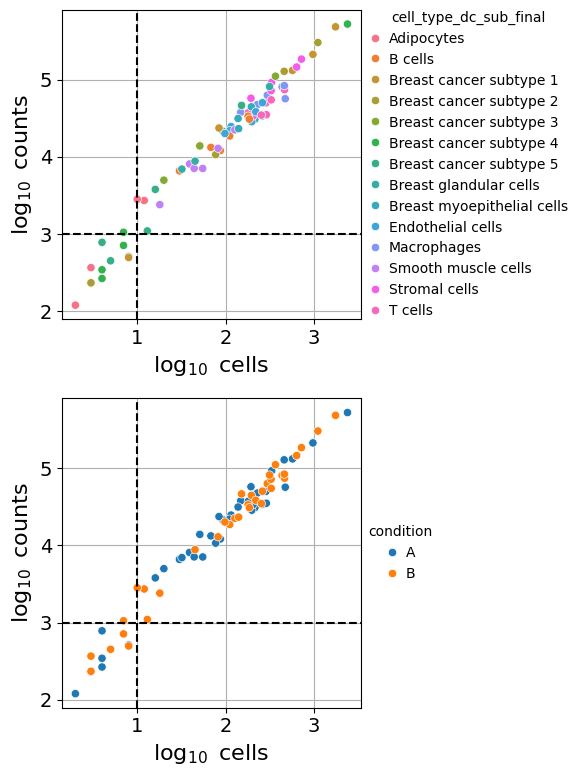

In [12]:
dc.pl.filter_samples(
    adata=pdata,
    groupby=["cell_type_dc_sub_final", "condition"],
    min_cells=10,
    min_counts=1000,
    figsize=(6, 8),
)

Since this example is only a dummy dataset, no actual analysis is possible. More information on how to continue with the pseudobulk analysis can be found in [this tutorial](https://decoupler.readthedocs.io/en/latest/notebooks/scell/rna_psbk.html#pseudobulking).

### Generating pseudobulk with consideration of neighborhood

Imaging-based spatial transcriptomics methods like Xenium In Situ or Merscope rely on cell segmentation to assign transcripts to the cells. This process is error-prone and can lead to transcripts being assigned to the wrong cell. Therefore, the gene expression of a cell can be influenced by cells in the direct neighborhood. To account for this it can make sense to investigate the gene expression of these neighboring cells to identify potential contaminations. Using `calculate_neighbors=True` in the `generate_pseudobulk` function one can calculate also a pseudobulk measurement of such neighboring cells to later explore their gene expression compared to the target cells.

In [13]:
# set up the DGE analysis
dge_setup = ["condition", "A", "B"]
celltype_col = "cell_type_dc_sub_final"
celltype = "Endothelial cells"

In [14]:
pdata, pdata_nb = pseudobulk(
    exp=exp,
    celltype_col=celltype_col,
    cells_layer='main',
    counts_layer='counts',
    calculate_neighbors=True,
    metadata_to_transfer=dge_setup[0]
    )

In [15]:
pdata

AnnData object with n_obs × n_vars = 73 × 297
    obs: 'uid', 'cell_type_dc_sub_final', 'psbulk_cells', 'psbulk_counts', 'condition', 'obs_type'
    uns: 'pseudobulk_settings'
    layers: 'psbulk_props'

In [16]:
pdata_nb

AnnData object with n_obs × n_vars = 73 × 297
    obs: 'uid', 'psbulk_cells', 'psbulk_counts', 'cell_type_dc_sub_final', 'condition', 'obs_type'
    uns: 'pseudobulk_settings'
    layers: 'psbulk_props'

In [17]:
pdata.obs

,uid,cell_type_dc_sub_final,psbulk_cells,psbulk_counts,condition,obs_type
41ef2fe9_B cells,41ef2fe9,B cells,86.0,12128.0,A,cells
41ef2fe9_Breast cancer subtype 1,41ef2fe9,Breast cancer subtype 1,568.0,132467.0,A,cells
41ef2fe9_Breast cancer subtype 2,41ef2fe9,Breast cancer subtype 2,76.0,10725.0,A,cells
41ef2fe9_Breast cancer subtype 3,41ef2fe9,Breast cancer subtype 3,50.0,13919.0,A,cells
41ef2fe9_Breast cancer subtype 4,41ef2fe9,Breast cancer subtype 4,2379.0,528355.0,A,cells
...,...,...,...,...,...,...
d7a51683_Endothelial cells,d7a51683,Endothelial cells,218.0,38530.0,B,cells
d7a51683_Macrophages,d7a51683,Macrophages,459.0,84097.0,B,cells
d7a51683_Smooth muscle cells,d7a51683,Smooth muscle cells,81.0,12949.0,B,cells
d7a51683_Stromal cells,d7a51683,Stromal cells,633.0,146404.0,B,cells


In [18]:
pdata_nb.obs

,uid,psbulk_cells,psbulk_counts,cell_type_dc_sub_final,condition,obs_type
41ef2fe9_Macrophages_neighbors,41ef2fe9,1400.0,217849.0,Macrophages,A,neighbors
41ef2fe9_Breast cancer subtype 5_neighbors,41ef2fe9,963.0,159012.0,Breast cancer subtype 5,A,neighbors
41ef2fe9_Breast cancer subtype 4_neighbors,41ef2fe9,3387.0,667490.0,Breast cancer subtype 4,A,neighbors
41ef2fe9_Breast myoepithelial cells_neighbors,41ef2fe9,908.0,152049.0,Breast myoepithelial cells,A,neighbors
41ef2fe9_Breast cancer subtype 1_neighbors,41ef2fe9,1636.0,345150.0,Breast cancer subtype 1,A,neighbors
...,...,...,...,...,...,...
d7a51683_Endothelial cells_neighbors,d7a51683,837.0,141330.0,Endothelial cells,B,neighbors
d7a51683_B cells_neighbors,d7a51683,714.0,108478.0,B cells,B,neighbors
d7a51683_Breast cancer subtype 1_neighbors,d7a51683,66.0,12464.0,Breast cancer subtype 1,B,neighbors
d7a51683_Breast cancer subtype 4_neighbors,d7a51683,57.0,12239.0,Breast cancer subtype 4,B,neighbors


In [19]:
from insitupy.tools import pseudobulk_dge

In [20]:
pdata.uns["pseudobulk_settings"]

{'celltype_col': 'cell_type_dc_sub_final',
 'cells_layer': 'main',
 'counts_layer': 'counts',
 'uid_col': 'uid',
 'mode': 'sum',
 'calculate_neighbors': True,
 'neighbors_radius': 20,
 'metadata_to_transfer': ['condition']}

In [51]:
pdata.shape[0]

60

Sample filtering QC:


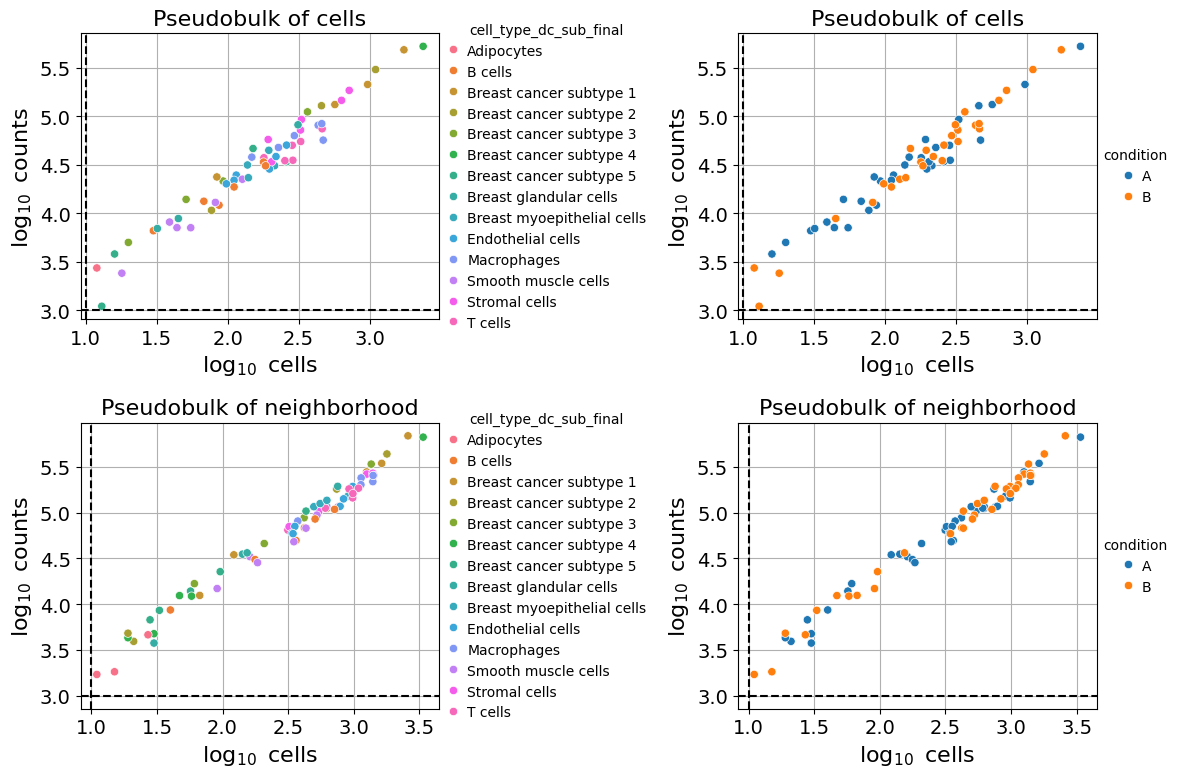

Filtered pseudobulk samples: 0 removed, 60 remaining (out of 60 total).
Filtered pseudobulk samples: 0 removed, 72 remaining (out of 72 total).
Feature filtering QC:


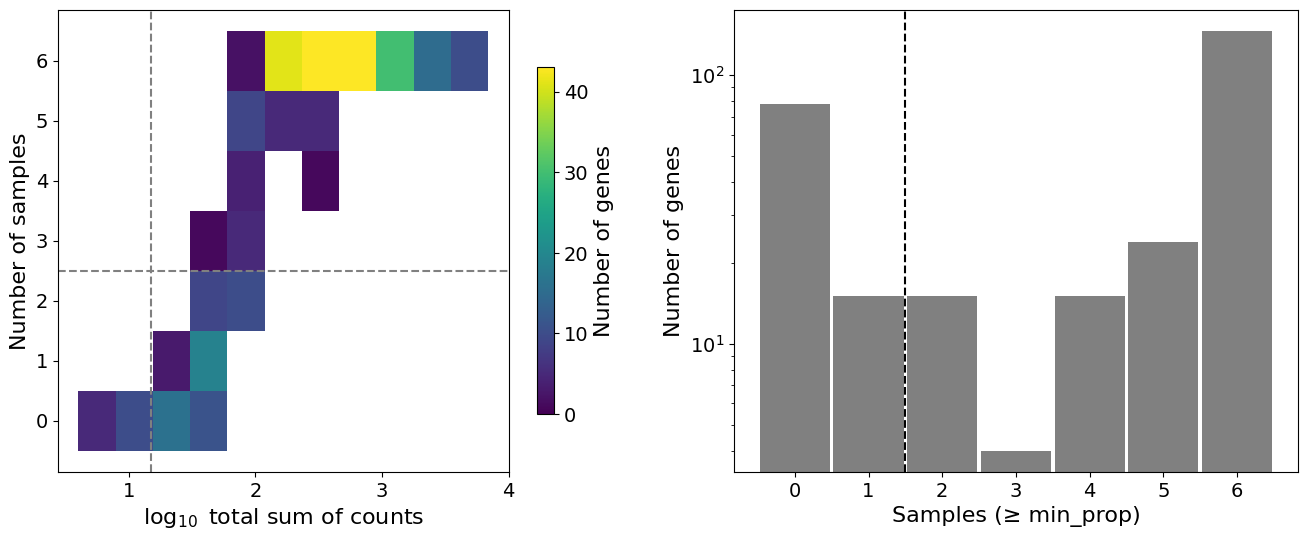

Filtered features: 94 removed, 203 remaining (out of 297 total).


In [58]:
dge_results = pseudobulk_dge(
    pdata=pdata,
    pdata_nb=pdata_nb,
    dge_setup=dge_setup,
    celltype_col=celltype_col,
    celltype=celltype,
    plot_qc=True,
    min_cells=10,
    min_counts=1000
)

In [65]:
from insitupy.plotting import volcano

In [66]:
dge_results.metadata["dge_setup"]

['condition', 'A', 'B']

In [67]:
dge_results.summary()

"Main DGE results: 203 genes\nNeighbor comparison (A): 203 genes\nNeighbor comparison (B): 203 genes\nMetadata: {'celltype': 'Endothelial cells', 'dge_setup': ['condition', 'A', 'B'], 'min_cells': 10, 'min_counts': 1000}"

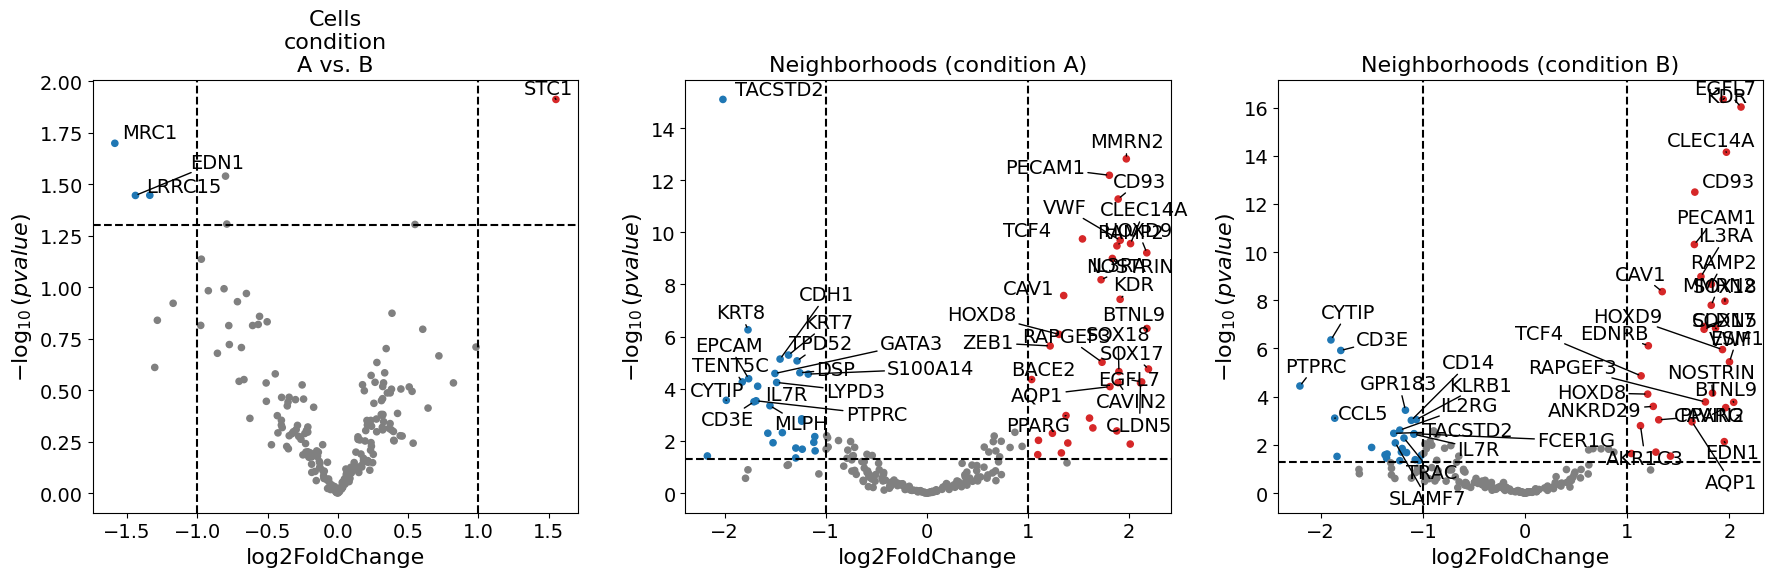

In [75]:
volcano(results=dge_results, backend="decoupler")

In [83]:
import numpy as np

In [85]:
np.max(-np.log10(dge_results.main["pvalue"]))

np.float64(1.9124291456783165)

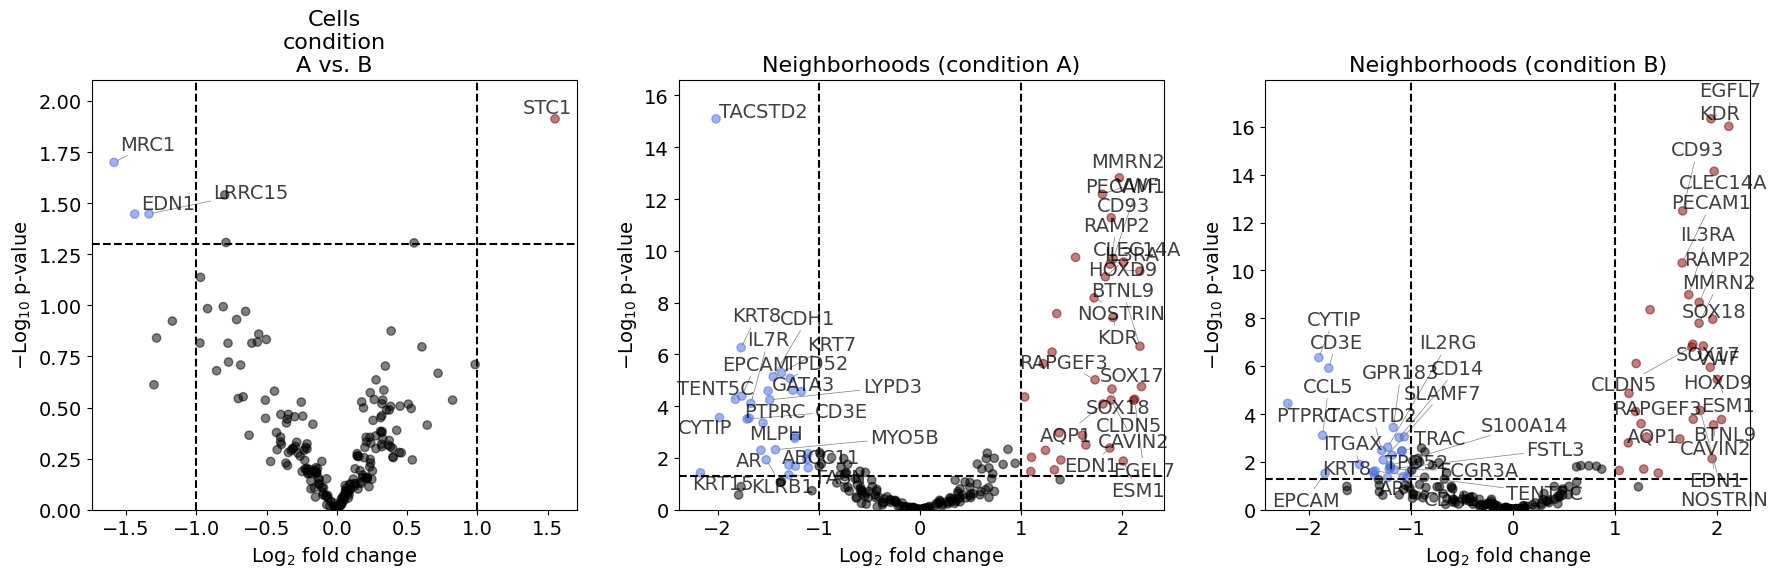

In [91]:
volcano(results=dge_results, backend="insitupy")

In [48]:
dge_results.main

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,neg_log10_pvals,gene
TCEAL7,14.139261,-0.856384,0.681446,-1.256715,0.208857,0.982020,0.680151,TCEAL7
SERPINA3,100.831411,-0.975086,0.682223,-1.429277,0.152925,0.982020,0.815522,SERPINA3
OXTR,15.094360,-0.471952,0.854059,-0.552599,0.580538,0.982020,0.236169,OXTR
VOPP1,161.342075,0.143576,0.229435,0.625781,0.531459,0.982020,0.274530,VOPP1
SLAMF7,18.829186,-0.625277,0.796155,-0.785371,0.432236,0.982020,0.364279,SLAMF7
...,...,...,...,...,...,...,...,...
BASP1,98.735378,0.026603,0.421820,0.063067,0.949714,0.996008,0.022407,BASP1
CCND1,622.828885,0.265106,0.249948,1.060645,0.288851,0.982020,0.539326,CCND1
PIM1,40.900636,-0.226760,0.471117,-0.481324,0.630286,0.982020,0.200462,PIM1
GPR183,22.124660,-0.277934,0.441524,-0.629487,0.529030,0.982020,0.276520,GPR183


In [22]:
dge_results

<PseudobulkDGEResults main=203 genes, neighbors=True>

In [ ]:
from

In [52]:
dge_results.get_all_results()

{'main':             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
 TCEAL7     14.139261       -0.856384  0.681446 -1.256715  0.208857  0.982020
 SERPINA3  100.831411       -0.975086  0.682223 -1.429277  0.152925  0.982020
 OXTR       15.094360       -0.471952  0.854059 -0.552599  0.580538  0.982020
 VOPP1     161.342075        0.143576  0.229435  0.625781  0.531459  0.982020
 SLAMF7     18.829186       -0.625277  0.796155 -0.785371  0.432236  0.982020
 ...              ...             ...       ...       ...       ...       ...
 BASP1      98.735378        0.026603  0.421820  0.063067  0.949714  0.996008
 CCND1     622.828885        0.265106  0.249948  1.060645  0.288851  0.982020
 PIM1       40.900636       -0.226760  0.471117 -0.481324  0.630286  0.982020
 GPR183     22.124660       -0.277934  0.441524 -0.629487  0.529030  0.982020
 RAB30      39.186320        0.034159  0.380670  0.089733  0.928499  0.996008
 
 [203 rows x 6 columns],
 'nb_condition_a':           

## Plan

Starting from this point, implement `insitupy.pl.pseudobulk_dge()`
- Input: `AnnData` (one or two depending on with or without neighbors)
- Optional output of QC filtering plots
- Optional filtering parameters
- if neighbors pseudobulk `AnnData` is given, the neighbor DGE plot is returned
- if `qc_plots=True` also the three volcanos are returned

In [16]:
pdata

AnnData object with n_obs × n_vars = 73 × 297
    obs: 'uid', 'cell_type_dc_sub_final', 'psbulk_cells', 'psbulk_counts', 'condition'
    layers: 'psbulk_props'

In [17]:
pdata.obs

,uid,cell_type_dc_sub_final,psbulk_cells,psbulk_counts,condition
c24fde38_B cells,c24fde38,B cells,86.0,12128.0,A
c24fde38_Breast cancer subtype 1,c24fde38,Breast cancer subtype 1,568.0,132467.0,A
c24fde38_Breast cancer subtype 2,c24fde38,Breast cancer subtype 2,76.0,10725.0,A
c24fde38_Breast cancer subtype 3,c24fde38,Breast cancer subtype 3,50.0,13919.0,A
c24fde38_Breast cancer subtype 4,c24fde38,Breast cancer subtype 4,2379.0,528355.0,A
...,...,...,...,...,...
4182c344_Endothelial cells,4182c344,Endothelial cells,218.0,38530.0,B
4182c344_Macrophages,4182c344,Macrophages,459.0,84097.0,B
4182c344_Smooth muscle cells,4182c344,Smooth muscle cells,81.0,12949.0,B
4182c344_Stromal cells,4182c344,Stromal cells,633.0,146404.0,B


In [18]:
pdata_nb

AnnData object with n_obs × n_vars = 73 × 297
    obs: 'uid', 'psbulk_cells', 'psbulk_counts', 'cell_type_dc_sub_final', 'condition'
    layers: 'psbulk_props'

In [19]:
pdata_nb.obs

,uid,psbulk_cells,psbulk_counts,cell_type_dc_sub_final,condition
c24fde38_Macrophages_neighbors,c24fde38,1400.0,217849.0,Macrophages,A
c24fde38_Breast cancer subtype 5_neighbors,c24fde38,963.0,159012.0,Breast cancer subtype 5,A
c24fde38_Breast cancer subtype 4_neighbors,c24fde38,3387.0,667490.0,Breast cancer subtype 4,A
c24fde38_Breast myoepithelial cells_neighbors,c24fde38,908.0,152049.0,Breast myoepithelial cells,A
c24fde38_Breast cancer subtype 1_neighbors,c24fde38,1636.0,345150.0,Breast cancer subtype 1,A
...,...,...,...,...,...
4182c344_Endothelial cells_neighbors,4182c344,837.0,141330.0,Endothelial cells,B
4182c344_B cells_neighbors,4182c344,714.0,108478.0,B cells,B
4182c344_Breast cancer subtype 1_neighbors,4182c344,66.0,12464.0,Breast cancer subtype 1,B
4182c344_Breast cancer subtype 4_neighbors,4182c344,57.0,12239.0,Breast cancer subtype 4,B


### Filtering

Only pseudobulk samples representing a sufficient number of cells and contain a sufficient number of counts should be included into the analysis. In the next step, we filter for these parameters.

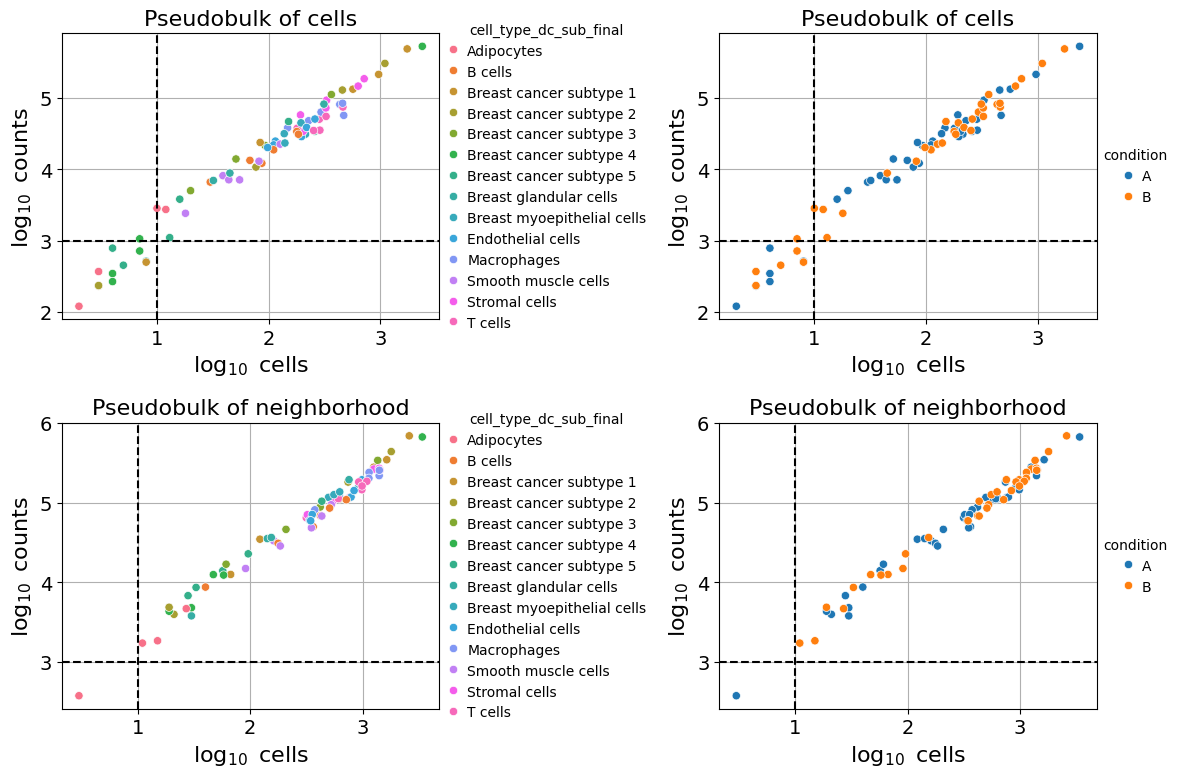

In [20]:
data_list = [pdata, pdata_nb]
data_names = ["Pseudobulk of cells", "Pseudobulk of neighborhood"]
groups = [celltype_col, dge_setup[0]]
ncols = len(groups)
nrows = len(data_list)
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(6*ncols, 4*nrows))

for r, d in enumerate(data_list):
    for c, g in enumerate(groups):
        dc.pl.filter_samples(
            adata=d,
            groupby=g,
            min_cells=10,
            min_counts=1000,
            ax=axs[r,c]
        )

        axs[r,c].set_title(f"{data_names[r]}")

plt.tight_layout()
plt.show()

Based on these plots we can see that most of the pseudobulk samples have enough cells and counts to be included into the analysis. In the next steps we apply the thresholds and do the filtering.

In [21]:
dc.pp.filter_samples(pdata, min_cells=10, min_counts=1000)
dc.pp.filter_samples(pdata_nb, min_cells=10, min_counts=1000)

### Select cell type for DGE analysis

In [22]:
pdata_ct = pdata[pdata.obs[celltype_col] == celltype, :].copy()
pdata_ct_nb = pdata_nb[pdata_nb.obs[celltype_col] == celltype, :].copy()

In [22]:
pdata_ct

AnnData object with n_obs × n_vars = 6 × 297
    obs: 'uid', 'cell_type_dc_sub_final', 'psbulk_cells', 'psbulk_counts', 'condition'
    layers: 'psbulk_props'

## Feature selection

Feature selection should be done for each cell type separately, since the gene expression depends a lot on the cell type.

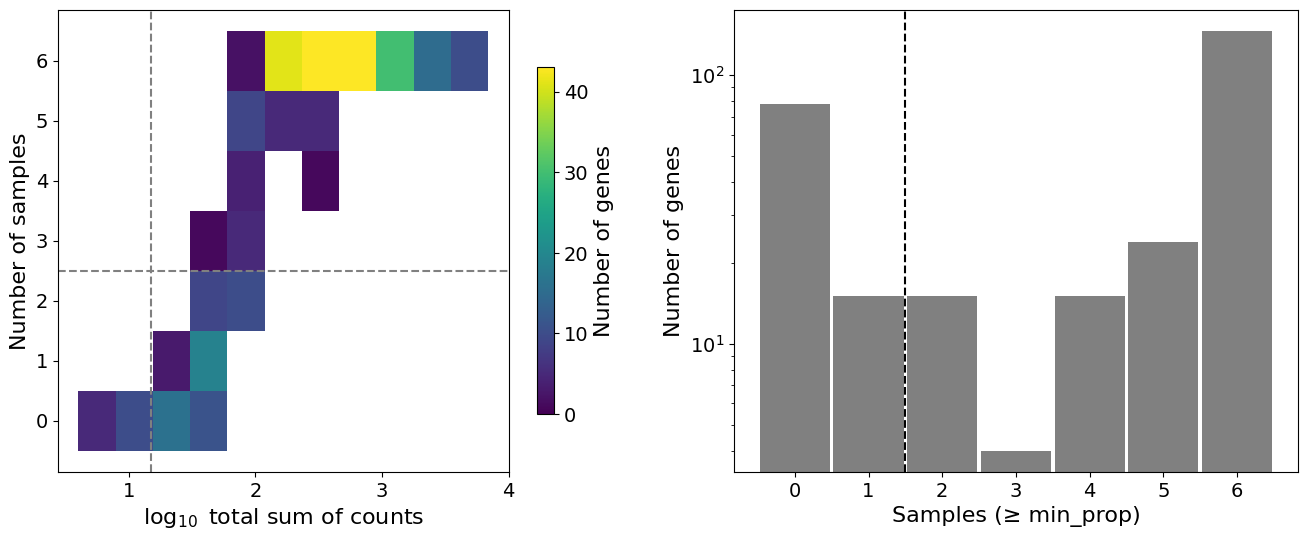

In [23]:
fig, axs = plt.subplots(1,2, figsize=(8*2, 6))
dc.pl.filter_by_expr(
    adata=pdata_ct,
    group="condition",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
    ax=axs[0]
)
dc.pl.filter_by_prop(
    adata=pdata_ct,
    min_prop=0.1,
    min_smpls=2,
    ax=axs[1]
)
plt.show()

In [ ]:
# filter features
dc.pp.filter_by_expr(
    adata=pdata_ct,
    group="condition",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
dc.pp.filter_by_prop(
    adata=pdata_ct,
    min_prop=0.1,
    min_smpls=2,
)

Now we can select the same features in the neighbor dataset.

In [25]:
pdata_ct_nb = pdata_ct_nb[:, pdata_ct_nb.var_names.isin(pdata_ct.var_names)].copy()

### Preprocessing of pseudobulk data

In [26]:
def preprocess_data(adata):
    # Store raw counts in layers
    adata.layers["counts"] = adata.X.copy()

    # Normalize, scale and compute pca
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.scale(adata, max_value=10)
    sc.tl.pca(adata)

    # Return raw counts to X
    dc.pp.swap_layer(adata=adata, key="counts", inplace=True)

    return adata

# do preprocessing
pdata_ct = preprocess_data(pdata_ct)
pdata_ct_nb = preprocess_data(pdata_ct_nb)

### Setup datasets for DGE analysis with neighborhoods

For the DGE analysis including the neighbors, we need to make three different statistical comparisons:
1. Cells of cell_type X in condition A vs. condition B
    - This can be made on `pdata`
2. Cells of cell_type X in condition A vs. neighboring cells in condition A
3. Cells of cell_type X in condition B vs. neighboring cells in condition B

The two sided volcano plots consist then of following parameters:
- X: Point 1, Y: Point 2
- X: Point 1 reversed, Y: Point 3

In [27]:
import anndata as ad

pdata_first_condition = ad.concat({
    "cells": pdata_ct[pdata_ct.obs[dge_setup[0]] == dge_setup[1]],
    "neighbors": pdata_ct_nb[pdata_ct_nb.obs[dge_setup[0]] == dge_setup[1]],
}, label="obs_type")

pdata_second_condition = ad.concat({
    "cells": pdata_ct[pdata_ct.obs[dge_setup[0]] == dge_setup[2]],
    "neighbors": pdata_ct_nb[pdata_ct_nb.obs[dge_setup[0]] == dge_setup[2]],
}, label="obs_type")

pdata_ct.obs["obs_type"] = "cells"

#### Calculating differentially expressed genes

⚠️ **Important note**: The following code is just an example. Due to the lack of meaningful conditions in this datasets, the results have no real significance. This tutorial is just to demonstrate the general concept. We will try to implement a more meaningful tutorial in the future.

In [28]:
def run_deseq2(adata, dge_setup):
    from pydeseq2.dds import DeseqDataSet, DefaultInference
    from pydeseq2.ds import DeseqStats
    # Build DESeq2 object
    inference = DefaultInference(n_cpus=8)
    dds = DeseqDataSet(
        adata=adata,
        design=f"~{dge_setup[0]}",
        refit_cooks=True,
        inference=inference,
    )

    # Compute LFCs
    dds.deseq2()

    # Extract contrast between conditions
    stat_res = DeseqStats(dds, contrast=dge_setup, inference=inference)

    # Compute Wald test
    stat_res.summary()

    return stat_res

# run DESeq2 for both conditions
stat_res = run_deseq2(pdata_ct, dge_setup=dge_setup)
stat_res_first = run_deseq2(pdata_first_condition, dge_setup=["obs_type", "cells", "neighbors"])
stat_res_second = run_deseq2(pdata_second_condition, dge_setup=["obs_type", "cells", "neighbors"])

# Extract results
results_df = stat_res.results_df
results_df_nb_first = stat_res_first.results_df
results_df_nb_second = stat_res_second.results_df

Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.16 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.12 seconds.

Fitting LFCs...
... done in 0.13 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.17 seconds.

Fitting size factors...
... done in 0.00 seconds.



Log2 fold change & Wald test p-value: condition A vs B
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
TCEAL7     14.139261       -0.856384  0.681446 -1.256715  0.208857  0.982020
SERPINA3  100.831411       -0.975086  0.682223 -1.429277  0.152925  0.982020
OXTR       15.094360       -0.471952  0.854059 -0.552599  0.580538  0.982020
VOPP1     161.342075        0.143576  0.229435  0.625781  0.531459  0.982020
SLAMF7     18.829186       -0.625277  0.796155 -0.785371  0.432236  0.982020
...              ...             ...       ...       ...       ...       ...
BASP1      98.735378        0.026603  0.421820  0.063067  0.949714  0.996008
CCND1     622.828885        0.265106  0.249948  1.060645  0.288851  0.982020
PIM1       40.900636       -0.226760  0.471117 -0.481324  0.630286  0.982020
GPR183     22.124660       -0.277934  0.441524 -0.629487  0.529030  0.982020
RAB30      39.186320        0.034159  0.380670  0.089733  0.928499  0.996008

[203 rows x 6 column

Fitting dispersions...
... done in 0.17 seconds.

Fitting dispersion trend curve...
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.14 seconds.

Fitting LFCs...
... done in 0.13 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.15 seconds.

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


Log2 fold change & Wald test p-value: obs_type cells vs neighbors
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
TCEAL7      15.718131        0.029246  0.706394  0.041402  0.966975  0.983001
SERPINA3   169.857821       -1.068293  0.804259 -1.328294  0.184081  0.336653
OXTR        25.867383       -0.578630  1.008900 -0.573525  0.566289  0.699190
VOPP1      258.095754        0.201572  0.280058  0.719751  0.471678  0.629939
SLAMF7      42.654832       -1.381457  0.806041 -1.713880  0.086551  0.186913
...               ...             ...       ...       ...       ...       ...
BASP1      167.276937       -0.083483  0.456860 -0.182731  0.855009  0.936253
CCND1     1107.843556        0.006432  0.343226  0.018740  0.985048  0.994850
PIM1        54.493571        0.315380  0.436514  0.722497  0.469989  0.629939
GPR183      51.245005       -1.105145  0.489737 -2.256608  0.024033  0.067258
RAB30       56.988037        0.396197  0.402177  0.985131  0.324559  0.49538

... done in 0.14 seconds.

Fitting dispersion trend curve...
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.14 seconds.

Fitting LFCs...
... done in 0.13 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.16 seconds.



Log2 fold change & Wald test p-value: obs_type cells vs neighbors
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
TCEAL7      38.239049        0.112318  0.627172  0.179087  0.857870  0.984517
SERPINA3   369.253368       -0.591137  0.813881 -0.726319  0.467643  0.713772
OXTR        32.981467        0.542059  0.456635  1.187071  0.235199  0.467345
VOPP1      336.178636        0.022524  0.231812  0.097165  0.922596  0.984517
SLAMF7      84.889624       -1.270426  0.481079 -2.640787  0.008271  0.039049
...               ...             ...       ...       ...       ...       ...
BASP1      256.730384       -0.480564  0.415231 -1.157339  0.247134  0.474292
CCND1     1234.364714        0.035665  0.370002  0.096392  0.923209  0.984517
PIM1       105.199901       -0.241432  0.430210 -0.561196  0.574664  0.815782
GPR183      87.687705       -1.171416  0.328587 -3.565012  0.000364  0.002736
RAB30       86.900815       -0.036018  0.382071 -0.094269  0.924895  0.98451

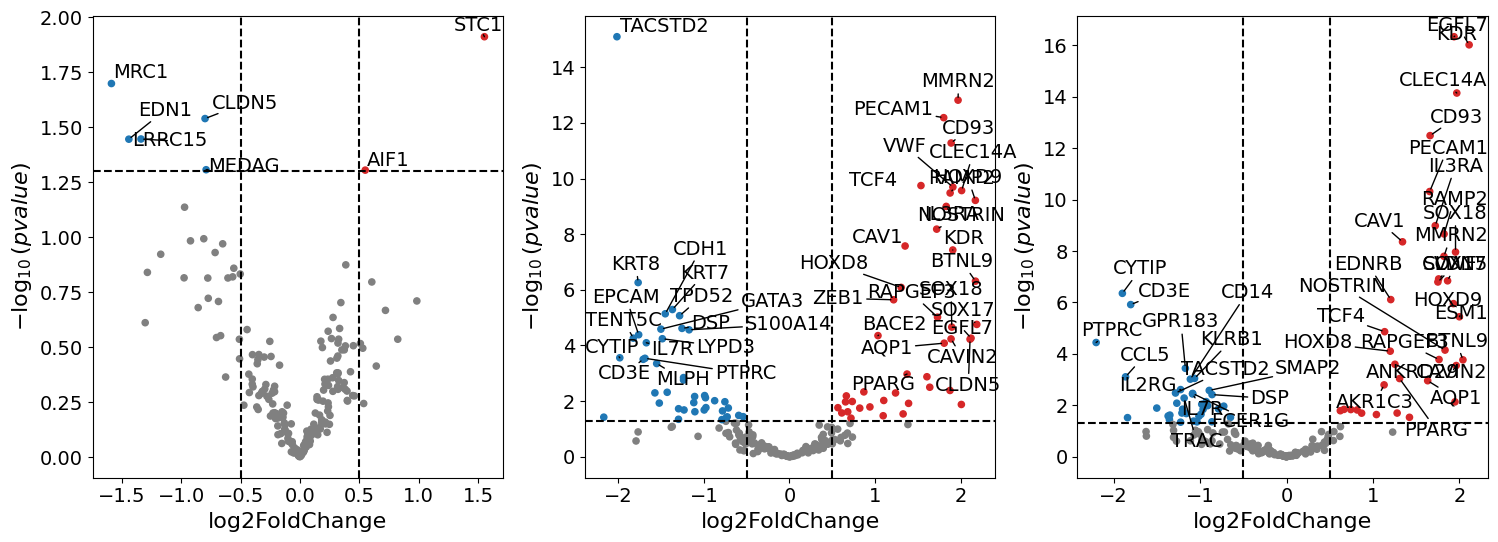

In [29]:
titles = ["Cells", "Neighborhoods (condition A)", "Neighborhoods (condition B)"]
fig, axs = plt.subplots(1,3, figsize=(6*3, 6))
for i, d in enumerate([results_df, results_df_nb_first, results_df_nb_second]):
    axs[i].set_title(titles[i])
    dc.pl.volcano(
        d,
        x="log2FoldChange",
        y="pvalue",
        top=40,
        ax=axs[i]
        )

### Differential expressed genes with Consideration of gene expression in neighboring cells of target dataset

In [30]:
from insitupy.plotting import volcano_nb

In [35]:
results_df.sort_values("log2FoldChange", ascending=False)[:10]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
STC1,42.618256,1.552160,0.619546,2.505320,0.012234,0.98202
TOP2A,53.314037,0.983508,0.758607,1.296467,0.194815,0.98202
CENPF,26.694345,0.822907,0.779076,1.056259,0.290850,0.98202
EPCAM,101.539657,0.719454,0.580242,1.239919,0.215005,0.98202
MLPH,59.747752,0.642235,0.739827,0.868087,0.385347,0.98202
S100A14,55.779857,0.604616,0.429980,1.406149,0.159680,0.98202
AIF1,80.345539,0.549303,0.279633,1.964370,0.049487,0.98202
MYH11,40.690712,0.536262,0.945131,0.567395,0.570446,0.98202
ANKRD30A,143.662662,0.528604,0.531122,0.995258,0.319611,0.98202
EIF4EBP1,32.833096,0.508238,0.494774,1.027214,0.304320,0.98202


In [36]:
results_df_nb_first.loc["AIF1"]

baseMean          157.610798
log2FoldChange     -0.064034
lfcSE               0.264523
stat               -0.242072
pvalue              0.808724
padj                0.907022
Name: AIF1, dtype: float64

In [45]:
import numpy as np
np.abs(-1)

np.int64(1)

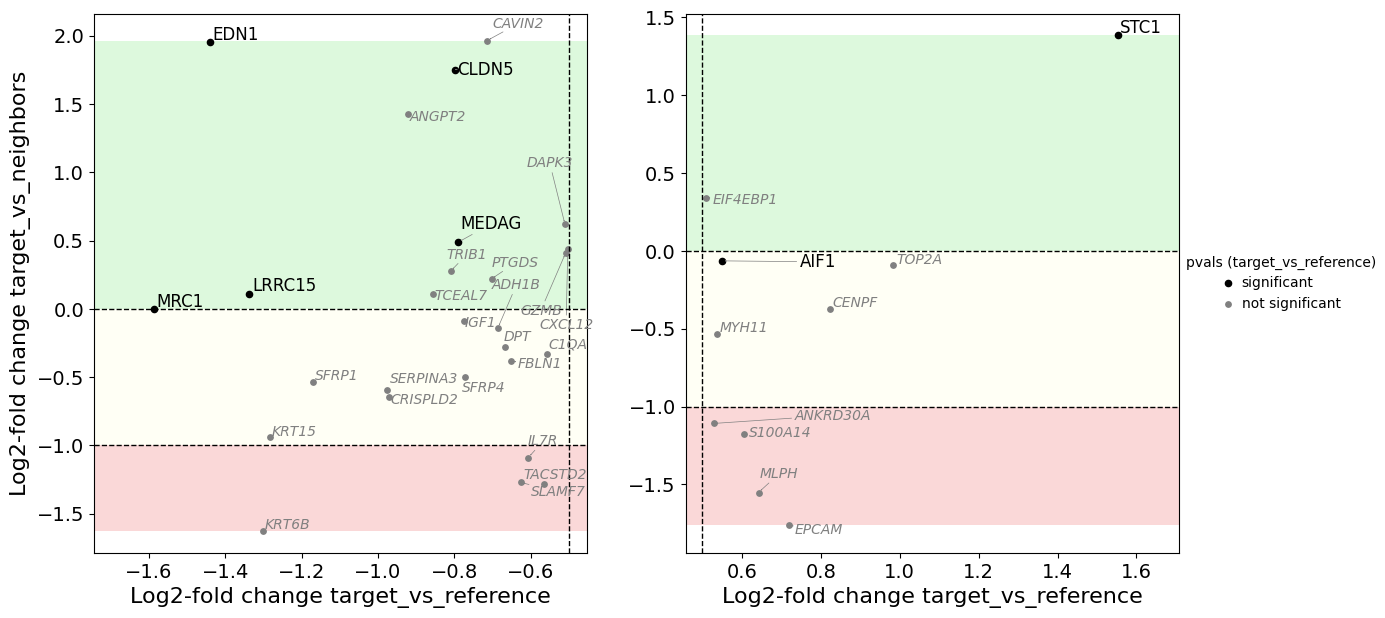

In [57]:
volcano_nb(
    results_df_normal=results_df,
    results_df_nb_first=results_df_nb_first,
    results_df_nb_second=results_df_nb_second,
    significance_threshold=0.05,
    fold_change_threshold=0.5)

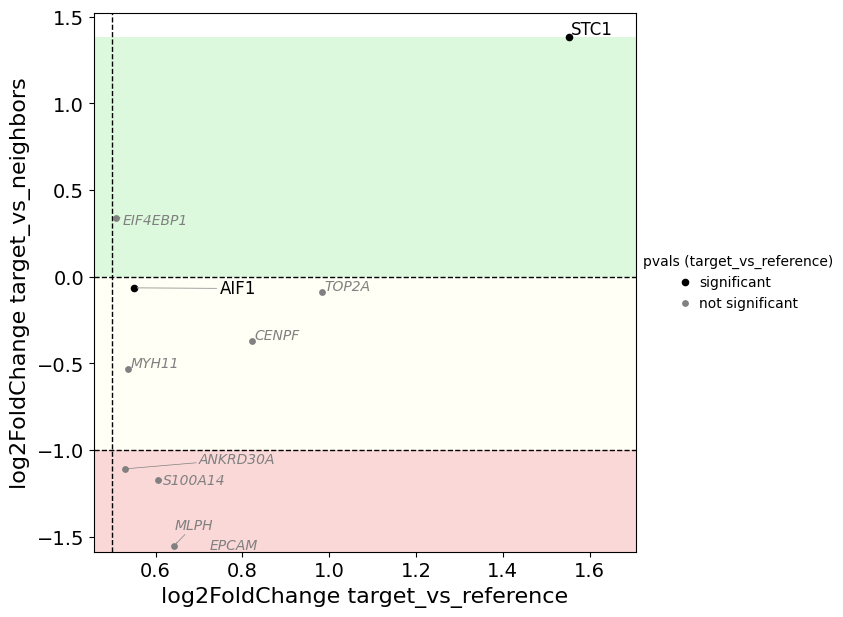

In [ ]:
volcano_nb(
    results_df_normal=results_df,
    results_df_neighbors=results_df_nb_first,
    significance_threshold=0.05,
    fold_change_threshold=0.5)

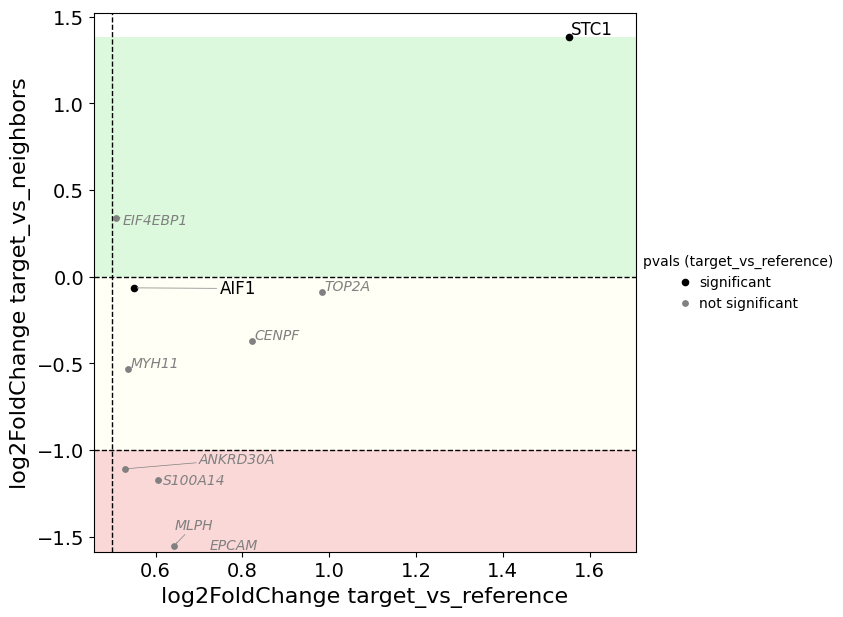

In [ ]:
volcano_nb(
    results_df_normal=results_df,
    results_df_neighbors=results_df_nb_first,
    significance_threshold=0.05,
    fold_change_threshold=0.5)

In [ ]:
insitupy.pl.dge()

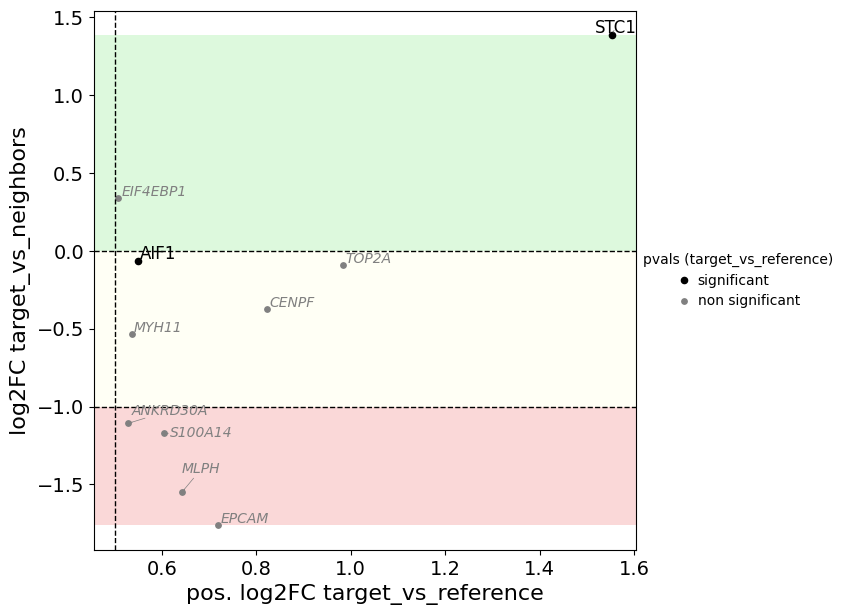

,gene,log2FoldChange_target_vs_reference,pvalue,log2FoldChange_target_vs_neighbors,neg_log10_pvals
0,EIF4EBP1,0.508238,0.304320,0.341737,0.516670
1,TOP2A,0.983508,0.194815,-0.089996,0.710378
2,CENPF,0.822907,0.290850,-0.370859,0.536331
3,S100A14,0.604616,0.159680,-1.173183,0.796750
4,STC1,1.552160,0.012234,1.384605,1.912429
5,ANKRD30A,0.528604,0.319611,-1.108266,0.495378
6,AIF1,0.549303,0.049487,-0.064034,1.305507
7,MYH11,0.536262,0.570446,-0.531950,0.243785
8,EPCAM,0.719454,0.215005,-1.762246,0.667551
9,MLPH,0.642235,0.385347,-1.551721,0.414148


In [ ]:
volcano_nb(
    results_df_normal=results_df,
    results_df_neighbors=results_df_nb_first,
    significance_threshold=0.05,
    fold_change_threshold=0.5)

['EIF4EBP1', 'TOP2A', 'CENPF', 'S100A14', 'STC1', 'ANKRD30A', 'AIF1', 'MYH11', 'EPCAM', 'MLPH']


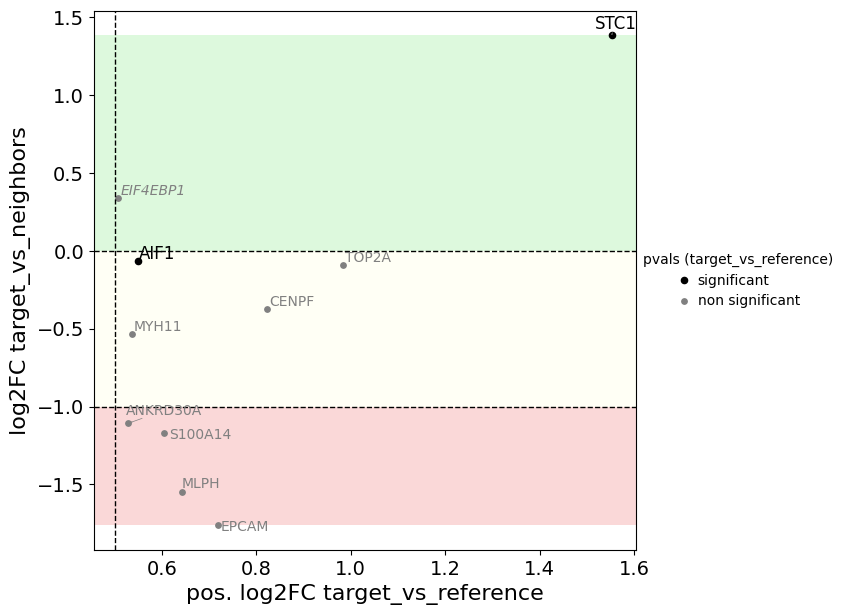

,gene,log2FoldChange_target_vs_reference,pvalue,log2FoldChange_target_vs_neighbors,neg_log10_pvals
0,EIF4EBP1,0.508238,0.304320,0.341737,0.516670
1,TOP2A,0.983508,0.194815,-0.089996,0.710378
2,CENPF,0.822907,0.290850,-0.370859,0.536331
3,S100A14,0.604616,0.159680,-1.173183,0.796750
4,STC1,1.552160,0.012234,1.384605,1.912429
5,ANKRD30A,0.528604,0.319611,-1.108266,0.495378
6,AIF1,0.549303,0.049487,-0.064034,1.305507
7,MYH11,0.536262,0.570446,-0.531950,0.243785
8,EPCAM,0.719454,0.215005,-1.762246,0.667551
9,MLPH,0.642235,0.385347,-1.551721,0.414148


In [ ]:
volcano_nb(
    results_df_normal=results_df,
    results_df_neighbors=results_df_nb_first,
    significance_threshold=0.05,
    fold_change_threshold=0.5)

['TOP2A', 'STC1']


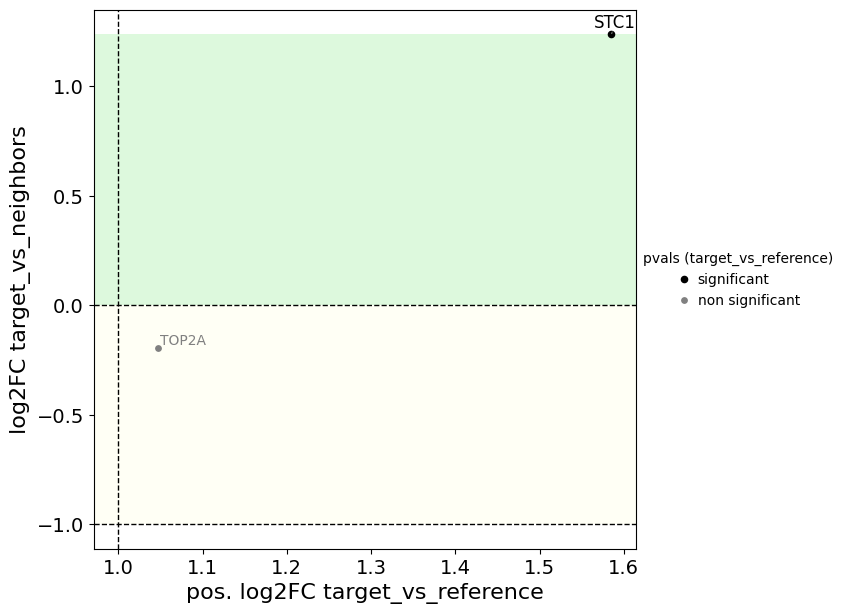

,gene,log2FoldChange_target_vs_reference,pvalue,log2FoldChange_target_vs_neighbors,neg_log10_pvals
0,TOP2A,1.046595,0.166498,-0.193782,0.778591
1,STC1,1.585409,0.009998,1.237953,2.000079


In [ ]:
volcano_nb(
    results_df_normal=results_df_endo,
    results_df_neighbors=results_df_neighbors,
    significance_threshold=0.05,
    fold_change_threshold=1.0)